In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms

import timm

print("="*60)
print("PyTorch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
print("="*60)

PyTorch : 2.10.0+cu128
CUDA : True


In [3]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

Device : cuda


In [4]:
# ============================================================
# Automatically Locate Dataset Paths
# ============================================================

import os

BASE_ROOT = "/kaggle/input/notebooks/mdrashidshahariar"

RAW_ROOT = None
HILBERT_ROOT = None
SCALOGRAM_ROOT = None

for root, dirs, files in os.walk(BASE_ROOT):

    # Notebook 4
    if "Prepared_Dataset" in dirs:
        RAW_ROOT = os.path.join(root, "Prepared_Dataset")

    # Notebook 5
    if "Hilbert_Dataset" in dirs:
        HILBERT_ROOT = os.path.join(root, "Hilbert_Dataset")

    # Notebook 6
    if "Wavelet_Dataset" in dirs:
        SCALOGRAM_ROOT = os.path.join(root, "Wavelet_Dataset")

print("=" * 70)
print("RAW ROOT       :", RAW_ROOT)
print("HILBERT ROOT   :", HILBERT_ROOT)
print("SCALOGRAM ROOT :", SCALOGRAM_ROOT)
print("=" * 70)

RAW ROOT       : /kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset
HILBERT ROOT   : /kaggle/input/notebooks/mdrashidshahariar/notebook-05-hilbert-spectogram/Hilbert_Dataset
SCALOGRAM ROOT : /kaggle/input/notebooks/mdrashidshahariar/notebook-06-wavelet-scalogram-images/Wavelet_Dataset


In [5]:
# ============================================================
# Configuration
# ============================================================

MINUTE = 30

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 2

NUM_WORKERS = 2

EPOCHS = 100

LEARNING_RATE = 1e-4

print("Prediction Window :", MINUTE)

print("Batch Size :", BATCH_SIZE)

Prediction Window : 30
Batch Size : 32


In [6]:
# ============================================================
# Load Raw ECG Dataset
# ============================================================

raw_folder = os.path.join(
    RAW_ROOT,
    f"{MINUTE}_min"
)

X = np.load(
    os.path.join(raw_folder, "X.npy")
)

y = np.load(
    os.path.join(raw_folder, "y.npy")
)

print("="*60)
print("Raw ECG Loaded Successfully")
print("="*60)

print("ECG Shape :", X.shape)
print("Labels Shape :", y.shape)

print("Positive :", np.sum(y==1))
print("Negative :", np.sum(y==0))

Raw ECG Loaded Successfully
ECG Shape : (2400, 500, 2)
Labels Shape : (2400,)
Positive : 1200
Negative : 1200


In [7]:
# ============================================================
# Locate Image Folders
# ============================================================

hilbert_positive = os.path.join(
    HILBERT_ROOT,
    f"{MINUTE}_min",
    "Positive"
)

hilbert_negative = os.path.join(
    HILBERT_ROOT,
    f"{MINUTE}_min",
    "Negative"
)

scalogram_positive = os.path.join(
    SCALOGRAM_ROOT,
    f"{MINUTE}_min",
    "Positive"
)

scalogram_negative = os.path.join(
    SCALOGRAM_ROOT,
    f"{MINUTE}_min",
    "Negative"
)

print(hilbert_positive)
print(hilbert_negative)

print()

print(scalogram_positive)
print(scalogram_negative)

/kaggle/input/notebooks/mdrashidshahariar/notebook-05-hilbert-spectogram/Hilbert_Dataset/30_min/Positive
/kaggle/input/notebooks/mdrashidshahariar/notebook-05-hilbert-spectogram/Hilbert_Dataset/30_min/Negative

/kaggle/input/notebooks/mdrashidshahariar/notebook-06-wavelet-scalogram-images/Wavelet_Dataset/30_min/Positive
/kaggle/input/notebooks/mdrashidshahariar/notebook-06-wavelet-scalogram-images/Wavelet_Dataset/30_min/Negative


In [8]:
# ============================================================
# Count Images
# ============================================================

def count_images(folder):

    return len([
        f for f in os.listdir(folder)
        if f.endswith(".png")
    ])


print("="*60)

print("Hilbert")

print(
    "Positive :",
    count_images(hilbert_positive)
)

print(
    "Negative :",
    count_images(hilbert_negative)
)

print()

print("Scalogram")

print(
    "Positive :",
    count_images(scalogram_positive)
)

print(
    "Negative :",
    count_images(scalogram_negative)
)

print("="*60)

Hilbert
Positive : 1200
Negative : 1200

Scalogram
Positive : 1200
Negative : 1200


In [9]:
# ============================================================
# Build Ordered Image Lists
# ============================================================

hilbert_images = (
    sorted([
        os.path.join(hilbert_negative,f)
        for f in os.listdir(hilbert_negative)
        if f.endswith(".png")
    ])
    +
    sorted([
        os.path.join(hilbert_positive,f)
        for f in os.listdir(hilbert_positive)
        if f.endswith(".png")
    ])
)

scalogram_images = (
    sorted([
        os.path.join(scalogram_negative,f)
        for f in os.listdir(scalogram_negative)
        if f.endswith(".png")
    ])
    +
    sorted([
        os.path.join(scalogram_positive,f)
        for f in os.listdir(scalogram_positive)
        if f.endswith(".png")
    ])
)

print("Hilbert Images :", len(hilbert_images))
print("Scalogram Images :", len(scalogram_images))
print("Raw ECG :", len(X))

Hilbert Images : 2400
Scalogram Images : 2400
Raw ECG : 2400


In [10]:
# ============================================================
# Verify Dataset Alignment
# ============================================================

assert len(X) == len(y)
assert len(X) == len(hilbert_images)
assert len(X) == len(scalogram_images)

print("="*60)
print("✓ Raw ECG")
print("✓ Hilbert Images")
print("✓ Scalogram Images")
print("✓ Labels")
print("All datasets are perfectly aligned.")
print("="*60)

✓ Raw ECG
✓ Hilbert Images
✓ Scalogram Images
✓ Labels
All datasets are perfectly aligned.


Sample Index : 860
Label : 1


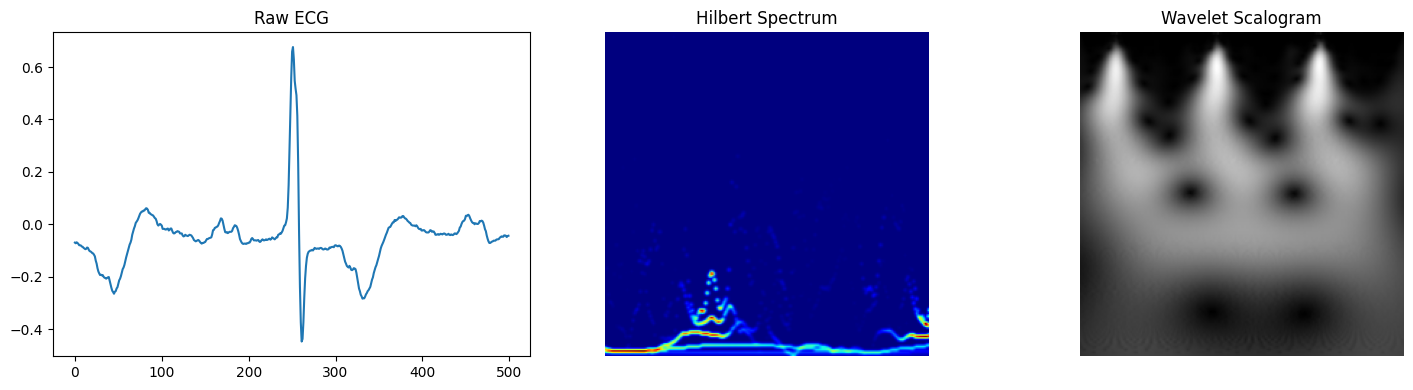

In [11]:
# ============================================================
# Visual Verification
# ============================================================

idx = np.random.randint(len(X))

print("Sample Index :", idx)
print("Label :", y[idx])

fig, ax = plt.subplots(1,3,figsize=(15,4))

ax[0].plot(X[idx][:,0])
ax[0].set_title("Raw ECG")

ax[1].imshow(Image.open(hilbert_images[idx]))
ax[1].set_title("Hilbert Spectrum")
ax[1].axis("off")

ax[2].imshow(Image.open(scalogram_images[idx]))
ax[2].set_title("Wavelet Scalogram")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Image Transformations
# ============================================================

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Created Successfully")

Transforms Created Successfully


In [13]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.20,
    random_state=SEED,
    stratify=y[train_idx]
)

print("="*60)

print("Training Samples   :", len(train_idx))
print("Validation Samples :", len(val_idx))
print("Testing Samples    :", len(test_idx))

print("="*60)

Training Samples   : 1536
Validation Samples : 384
Testing Samples    : 480


In [14]:
# ============================================================
# Multimodal Dataset
# ============================================================

class MultiModalDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        hilbert_images,
        scalogram_images,
        indices,
        transform=None
    ):

        self.X = X
        self.y = y

        self.hilbert_images = hilbert_images
        self.scalogram_images = scalogram_images

        self.indices = indices

        self.transform = transform

    def __len__(self):

        return len(self.indices)

    def __getitem__(self, idx):

        sample = self.indices[idx]

        ecg = self.X[sample]

        ecg = torch.tensor(
            ecg,
            dtype=torch.float32
        )

        hilbert = Image.open(
            self.hilbert_images[sample]
        ).convert("RGB")

        scalogram = Image.open(
            self.scalogram_images[sample]
        ).convert("RGB")

        if self.transform:

            hilbert = self.transform(hilbert)

            scalogram = self.transform(scalogram)

        label = torch.tensor(
            self.y[sample],
            dtype=torch.long
        )

        return {

            "ecg": ecg,

            "hilbert": hilbert,

            "scalogram": scalogram,

            "label": label

        }

print("Dataset Class Created Successfully")

Dataset Class Created Successfully


In [15]:
# ============================================================
# Dataset Objects
# ============================================================

train_dataset = MultiModalDataset(
    X,
    y,
    hilbert_images,
    scalogram_images,
    train_idx,
    transform=train_transform
)

val_dataset = MultiModalDataset(
    X,
    y,
    hilbert_images,
    scalogram_images,
    val_idx,
    transform=test_transform
)

test_dataset = MultiModalDataset(
    X,
    y,
    hilbert_images,
    scalogram_images,
    test_idx,
    transform=test_transform
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 1536
Validation : 384
Test : 480


In [16]:
# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders Created Successfully")

DataLoaders Created Successfully


In [17]:
# ============================================================
# Verify DataLoader
# ============================================================

batch = next(iter(train_loader))

print("="*60)

print("Raw ECG")

print(batch["ecg"].shape)

print()

print("Hilbert")

print(batch["hilbert"].shape)

print()

print("Scalogram")

print(batch["scalogram"].shape)

print()

print("Labels")

print(batch["label"].shape)

print("="*60)

Raw ECG
torch.Size([32, 500, 2])

Hilbert
torch.Size([32, 3, 224, 224])

Scalogram
torch.Size([32, 3, 224, 224])

Labels
torch.Size([32])


In [18]:
# ============================================================
# Raw ECG Encoder
# ============================================================

class ECGEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(2,64,kernel_size=7,padding=3),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(64,128,kernel_size=5,padding=2),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(128,256,kernel_size=3,padding=1),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)

        )

        self.fc = nn.Linear(256,512)

    def forward(self,x):

        x = x.permute(0,2,1)

        x = self.features(x)

        x = x.squeeze(-1)

        x = self.fc(x)

        return x

print("ECG Encoder Created")

ECG Encoder Created


In [19]:
# ============================================================
# Hilbert Encoder
# ============================================================

class HilbertEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(

            "efficientnet_b0",

            pretrained=True,

            num_classes=0

        )

    def forward(self,x):

        return self.backbone(x)

print("Hilbert Encoder Created")

Hilbert Encoder Created


In [20]:
# ============================================================
# Scalogram Encoder
# ============================================================

class ScalogramEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(

            "efficientnet_b0",

            pretrained=True,

            num_classes=0

        )

    def forward(self,x):

        return self.backbone(x)

print("Scalogram Encoder Created")

Scalogram Encoder Created


In [21]:
# ============================================================
# Multimodal Fusion Network
# ============================================================

class MultiModalNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.ecg = ECGEncoder()

        self.hilbert = HilbertEncoder()

        self.scalogram = ScalogramEncoder()

        self.classifier = nn.Sequential(

            nn.Linear(
                512+1280+1280,
                1024
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                NUM_CLASSES
            )

        )

    def forward(

        self,
        ecg,
        hilbert,
        scalogram

    ):

        ecg = self.ecg(ecg)

        hilbert = self.hilbert(hilbert)

        scalogram = self.scalogram(scalogram)

        x = torch.cat(

            [
                ecg,
                hilbert,
                scalogram
            ],

            dim=1

        )

        return self.classifier(x)

print("Multimodal Network Created")

Multimodal Network Created


In [22]:
# ============================================================
# Verify Model
# ============================================================

model = MultiModalNet().to(device)

batch = next(iter(train_loader))

with torch.no_grad():

    output = model(

        batch["ecg"].to(device),

        batch["hilbert"].to(device),

        batch["scalogram"].to(device)

    )

print("="*60)

print("Output Shape :", output.shape)

print("="*60)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Output Shape : torch.Size([32, 2])


In [23]:
# ============================================================
# Loss Function & Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

print("Loss Function :", criterion)
print("Optimizer :", optimizer.__class__.__name__)

Loss Function : CrossEntropyLoss()
Optimizer : AdamW


In [24]:
# ============================================================
# Train One Epoch
# ============================================================

def train_one_epoch(model, loader):

    model.train()

    total_loss = 0

    preds = []
    labels = []

    for batch in tqdm(loader):

        ecg = batch["ecg"].to(device)

        hilbert = batch["hilbert"].to(device)

        scalogram = batch["scalogram"].to(device)

        target = batch["label"].to(device)

        optimizer.zero_grad()

        output = model(
            ecg,
            hilbert,
            scalogram
        )

        loss = criterion(
            output,
            target
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds.extend(
            torch.argmax(output,1).cpu().numpy()
        )

        labels.extend(
            target.cpu().numpy()
        )

    accuracy = accuracy_score(labels,preds)

    f1 = f1_score(labels,preds)

    return total_loss/len(loader), accuracy, f1

In [25]:
# ============================================================
# Validation
# ============================================================

def validate(model, loader):

    model.eval()

    total_loss = 0

    preds = []

    labels = []

    with torch.no_grad():

        for batch in tqdm(loader):

            ecg = batch["ecg"].to(device)

            hilbert = batch["hilbert"].to(device)

            scalogram = batch["scalogram"].to(device)

            target = batch["label"].to(device)

            output = model(
                ecg,
                hilbert,
                scalogram
            )

            loss = criterion(
                output,
                target
            )

            total_loss += loss.item()

            preds.extend(
                torch.argmax(output,1).cpu().numpy()
            )

            labels.extend(
                target.cpu().numpy()
            )

    accuracy = accuracy_score(labels,preds)

    f1 = f1_score(labels,preds)

    return total_loss/len(loader), accuracy, f1

In [26]:
# ============================================================
# Model Training (Early Stopping)
# ============================================================

import copy

best_f1 = 0.0
best_epoch = 0

EARLY_STOPPING_PATIENCE = 10
early_stop_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

best_model_weights = None

for epoch in range(EPOCHS):

    print("=" * 70)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("=" * 70)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, val_f1 = validate(
        model,
        val_loader
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Train Loss : {train_loss:.6f}")
    print(f"Val Loss   : {val_loss:.6f}")

    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    # -------------------------------
    # Save Best Model
    # -------------------------------

    if val_f1 > best_f1:

        best_f1 = val_f1
        best_epoch = epoch + 1

        early_stop_counter = 0

        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch + 1,
                "best_f1": best_f1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "history": history
            },
            "best_model.pth"
        )

        print("✓ Best model saved.")

    else:

        early_stop_counter += 1

        print(
            f"No Improvement "
            f"({early_stop_counter}/{EARLY_STOPPING_PATIENCE})"
        )

        if early_stop_counter >= EARLY_STOPPING_PATIENCE:

            print("\nEarly stopping triggered.")
            break

print("\nTraining Finished.")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation F1 : {best_f1:.4f}")

# Restore best weights into model
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

Epoch 1/100


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.221932
Val Loss   : 0.001960
Train Acc  : 0.9421
Val Acc    : 1.0000
Train F1   : 0.9448
Val F1     : 1.0000
✓ Best model saved.
Epoch 2/100


  0%|          | 0/48 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.000293
Val Loss   : 0.000233
Train Acc  : 1.0000
Val Acc    : 1.0000
Train F1   : 1.0000
Val F1     : 1.0000
No Improvement (9/10)
Epoch 11/100


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Train Loss : 0.001190
Val Loss   : 0.000501
Train Acc  : 1.0000
Val Acc    : 1.0000
Train F1   : 1.0000
Val F1     : 1.0000
No Improvement (10/10)

Early stopping triggered.

Training Finished.
Best Epoch : 1
Best Validation F1 : 1.0000


In [27]:
import os

print("Exists :", os.path.exists("best_model.pth"))

if os.path.exists("best_model.pth"):
    print("Size :", os.path.getsize("best_model.pth")/1024/1024, "MB")

Exists : True
Size : 134.83071041107178 MB
